# Surface Roughness — Training & Model Comparison

This notebook tells the full training story behind the two surface-roughness
classifiers and explains, with evidence, **which model to ship**.

**Task.** Predict a machined surface's roughness class — **Smooth / Medium /
Rough** — from a microscopy image *plus* the abrasive grit value used during
machining. Labels come from cutting `Ra_Moyenne` at its 33rd / 67th percentiles.

**Models compared.**
- **ViT-GRiT** — a `vit_base_patch16_224` backbone whose CLS feature is
  concatenated with a learned grit embedding before an MLP head.
- **FiLM-ResNet50** — a ResNet-50 whose feature maps are modulated by the grit
  embedding via Feature-wise Linear Modulation (FiLM).

**Methodology in one line.** We compare them under two complementary protocols —
3 training seeds on a *fixed* test split, and 5-fold cross-validation — so we
can separate *training-randomness* variance from *data-partition* variance.

All numbers below are loaded from the saved run checkpoints; nothing is
hardcoded. The figures are the committed assets in `assets/`.

> **Reproducibility note.** The numeric cells read the local training outputs
> under `outputs/rigorous/` (gitignored). On GitHub the executed tables and
> figures are already rendered inline; re-running the numbers requires those
> local artifacts.

In [1]:
# %matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from IPython.display import Image as IPyImage, display


def find_project_root(start=None):
    # Walk up from the cwd until config.py is found (keeps paths machine-agnostic).
    here = Path(start or Path.cwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "config.py").exists():
            return cand
    raise FileNotFoundError("Could not locate the project root (config.py).")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import CLASSES, RA_THRESHOLDS

ASSETS = PROJECT_ROOT / "assets"
OUTPUTS = PROJECT_ROOT / "outputs" / "rigorous"
FIXED_DIR = OUTPUTS / "fixed_split"
KFOLD_DIR = OUTPUTS / "kfold"

MODELS = {"ViT-GRiT": "vit_grit", "FiLM-ResNet50": "film_resnet50"}
SEEDS = [42, 123, 2024]


def _status(found):
    return "✓ found" if found else "✗ missing"


def load_metrics(pth_path):
    # Checkpoints store a 'metrics' dict (accuracy, f1, per_class_f1, confusion_matrix).
    return torch.load(pth_path, map_location="cpu", weights_only=False)["metrics"]


def metrics_from_dir(directory):
    pths = sorted(Path(directory).glob("*.pth"))
    assert pths, f"No checkpoint found in {Path(directory).name}/"
    return load_metrics(pths[0])


def show_figure(filename):
    # Embed the committed PNG bytes directly (no local path stored in the output).
    display(IPyImage(data=(ASSETS / filename).read_bytes()))


print("Project root :", _status(PROJECT_ROOT.is_dir()))
print("Assets dir   :", _status(ASSETS.is_dir()))
print("Results dir  :", _status(OUTPUTS.is_dir()))
print("Classes      :", CLASSES)
print("Ra thresholds:", RA_THRESHOLDS, "µm")

Project root : ✓ found
Assets dir   : ✓ found
Results dir  : ✓ found
Classes      : ('Smooth', 'Medium', 'Rough')
Ra thresholds: (0.653, 0.96) µm


## 1. Methodology

### Group-stratified split (no leakage)
Every physical sample contributes **four images** (different viewing angles) that
share a single label. Splitting images independently would let near-duplicate
views of the same surface land in both train and test, inflating scores. We
therefore split at the **sample (group) level** — all four angles stay together —
and **stratify by grit** so every grade appears in each fold.

### Decoupled split seed vs. training seed
A single random seed conflates two very different things:
- **`split_seed`** decides *which samples* form train / val / test.
- **`seed`** decides *training* randomness — head initialisation, batch order, augmentation.

Controlling them separately lets us hold the **test set fixed** and vary **only
training randomness** — the apples-to-apples setup for comparing two models.

### Why both multi-seed *and* 5-fold CV
- **3 training seeds on a fixed split** isolates *sensitivity to training
  randomness*: is a model reproducible run-to-run?
- **5-fold cross-validation** isolates *sensitivity to the data partition* and
  evaluates on **all 90 samples** — essential for such a small dataset.

A single train/test accuracy would blend these two variance sources together;
measuring them separately is what makes the comparison trustworthy.

The cell below demonstrates both properties directly on the real split logic.

In [2]:
from config import Config
from data.dataset import load_labels, group_split, group_kfold_split

LABELS_CSV = PROJECT_ROOT / "old" / "Labelisation_CSV.csv"
rows = load_labels(str(LABELS_CSV))
all_groups = {r["group_id"] for r in rows}

# (a) Same split_seed -> identical test set, regardless of the training seed.
cfg_a = Config(labels_path=str(LABELS_CSV), output_dir="", split_seed=42, random_seed=42)
cfg_b = Config(labels_path=str(LABELS_CSV), output_dir="", split_seed=42, random_seed=123)
test_a = {r["group_id"] for r in group_split(rows, cfg_a)[2]}
test_b = {r["group_id"] for r in group_split(rows, cfg_b)[2]}
print(f"Fixed split (split_seed=42): {len(test_a)} test groups")
print(f"Identical test set for training seeds 42 vs 123: {test_a == test_b}")

# (b) 5-fold CV partitions every sample exactly once, with no within-fold leakage.
cfg_cv = Config(labels_path=str(LABELS_CSV), output_dir="", split_seed=42, kfold=5)
folds = group_kfold_split(rows, cfg_cv)
overlap = False
test_union = set()
for tr, va, te in folds:
    g = [{r["group_id"] for r in part} for part in (tr, va, te)]
    if (g[0] & g[1]) or (g[0] & g[2]) or (g[1] & g[2]):
        overlap = True
    test_union |= g[2]
g0 = [len({r["group_id"] for r in part}) for part in folds[0]]
print(f"\n5-fold CV: {len(folds)} folds, groups per fold (train/val/test) = {g0[0]}/{g0[1]}/{g0[2]}")
print(f"Any train/val/test overlap within a fold: {overlap}")
print(f"Test folds cover all {len(all_groups)} samples exactly once: {test_union == all_groups}")

Fixed split (split_seed=42): 14 test groups
Identical test set for training seeds 42 vs 123: True

5-fold CV: 5 folds, groups per fold (train/val/test) = 59/13/18
Any train/val/test overlap within a fold: False
Test folds cover all 90 samples exactly once: True


## 2. Results

We load the per-run metrics straight from the saved checkpoints — the fixed-split
runs (2 models × 3 seeds) and the 5-fold CV runs (2 models × 5 folds, which also
store each fold's confusion matrix).

In [3]:
fixed, cv = {}, {}

for disp, name in MODELS.items():
    accs, f1s = [], []
    for s in SEEDS:
        m = metrics_from_dir(FIXED_DIR / f"{name}_seed{s}")
        accs.append(m["accuracy"]); f1s.append(m["f1"])
    fixed[disp] = {"acc": np.array(accs), "f1": np.array(f1s)}

for disp, name in MODELS.items():
    accs, f1s, cms = [], [], []
    for fold_dir in sorted((KFOLD_DIR / name).glob("fold*")):
        m = metrics_from_dir(fold_dir)
        accs.append(m["accuracy"]); f1s.append(m["f1"])
        cms.append(np.asarray(m["confusion_matrix"], dtype=int))
    cv[disp] = {"acc": np.array(accs), "f1": np.array(f1s), "cms": cms}

print(f"Fixed-split runs loaded: {sum(len(v['acc']) for v in fixed.values())}")
print(f"CV folds loaded        : {sum(len(v['acc']) for v in cv.values())}")

Fixed-split runs loaded: 6
CV folds loaded        : 10


### 2.1 Benchmark comparison

Mean ± std for both protocols. The error bars are the headline: on the **fixed
split**, ViT-GRiT's bar has a huge spread while FiLM-ResNet50's is tight. Under
**5-fold CV** the two means are close. In other words, the models look similar on
average but behave very differently run-to-run.

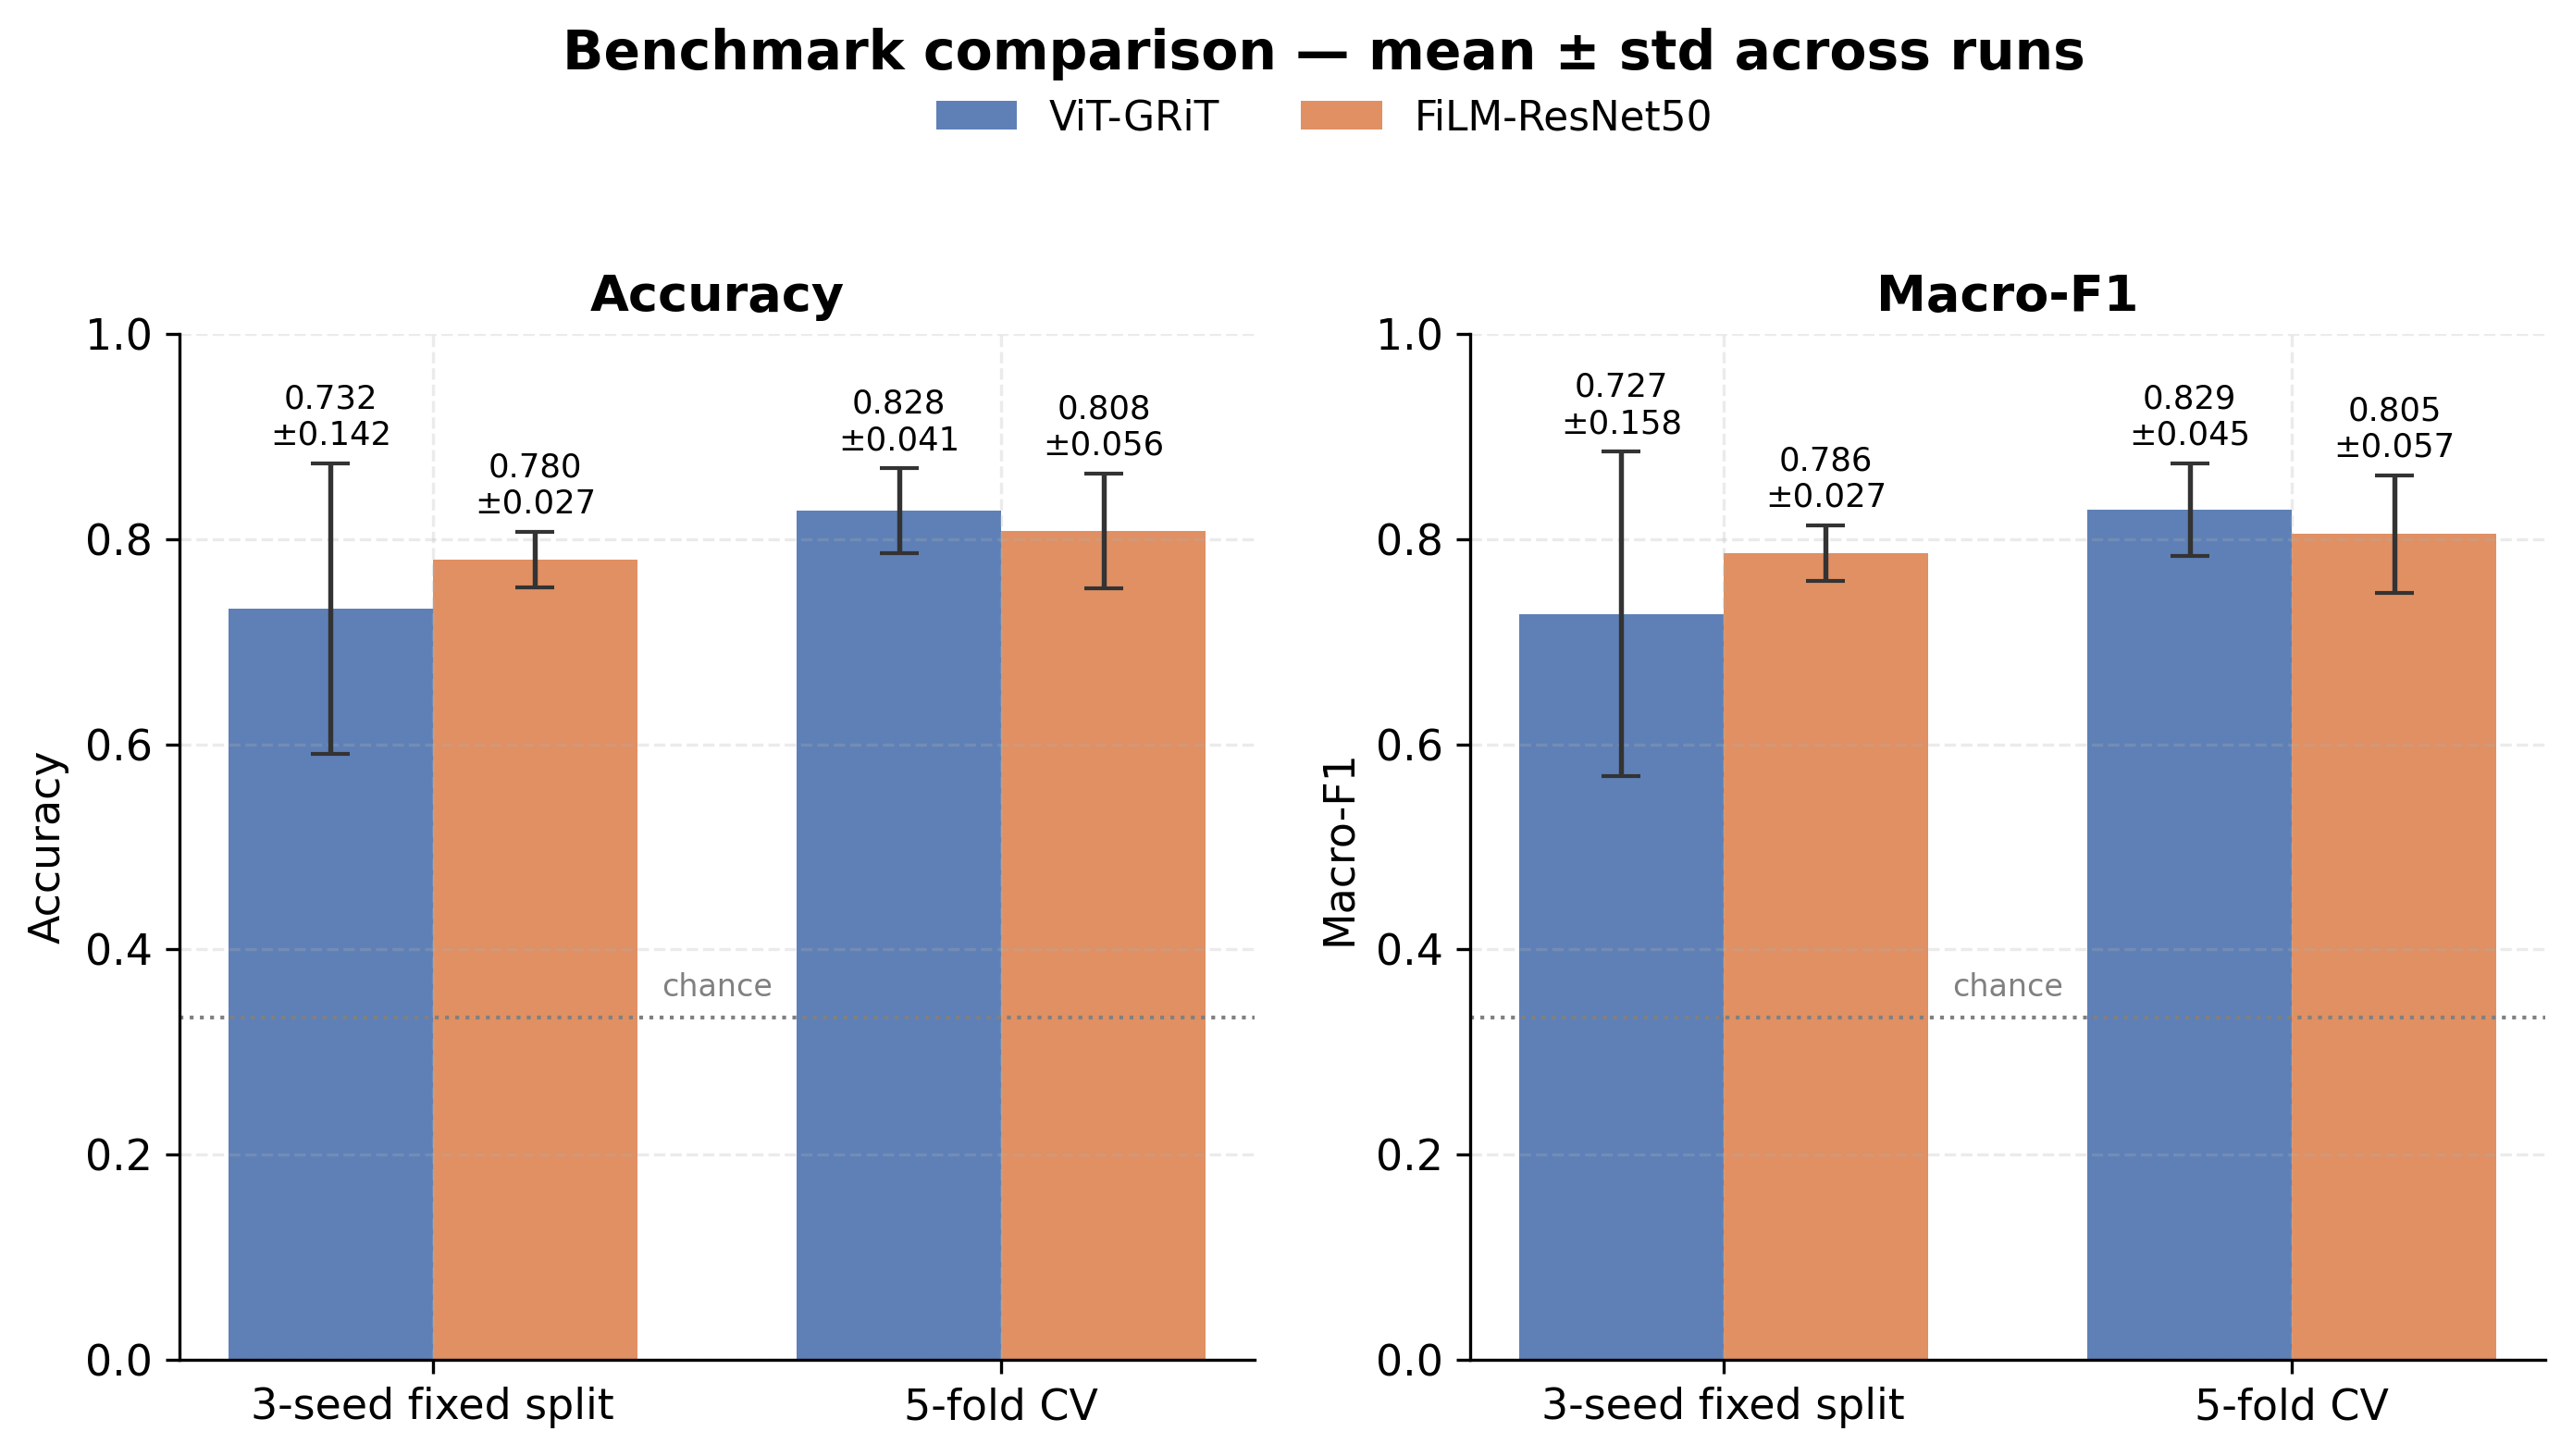

In [4]:
show_figure("benchmark_comparison.png")

### Model comparison table (mean ± std)

The same numbers, computed from the checkpoints.

In [5]:
def ms(a):
    return f"{a.mean():.3f} ± {a.std(ddof=1):.3f}"

table_rows = []
for key, label in [("acc", "Accuracy"), ("f1", "Macro-F1")]:
    table_rows.append(["3-seed fixed split", label,
                       ms(fixed["ViT-GRiT"][key]), ms(fixed["FiLM-ResNet50"][key])])
    table_rows.append(["5-fold CV", label,
                       ms(cv["ViT-GRiT"][key]), ms(cv["FiLM-ResNet50"][key])])

comparison = (pd.DataFrame(table_rows,
              columns=["Experiment", "Metric", "ViT-GRiT", "FiLM-ResNet50"])
              .set_index(["Experiment", "Metric"]))
comparison

,,ViT-GRiT,FiLM-ResNet50
Experiment,Metric,,
3-seed fixed split,Accuracy,0.732 ± 0.142,0.780 ± 0.027
5-fold CV,Accuracy,0.828 ± 0.041,0.808 ± 0.056
3-seed fixed split,Macro-F1,0.727 ± 0.158,0.786 ± 0.027
5-fold CV,Macro-F1,0.829 ± 0.045,0.805 ± 0.057


### 2.2 Confusion matrices (best CV fold per model)

Both best folds reach the same accuracy. Errors are almost entirely between
**adjacent** classes (Smooth↔Medium, Medium↔Rough) — never Smooth↔Rough — so the
models respect the ordinal nature of roughness. The Smooth/Medium boundary is the
hardest, as expected from the percentile cut.

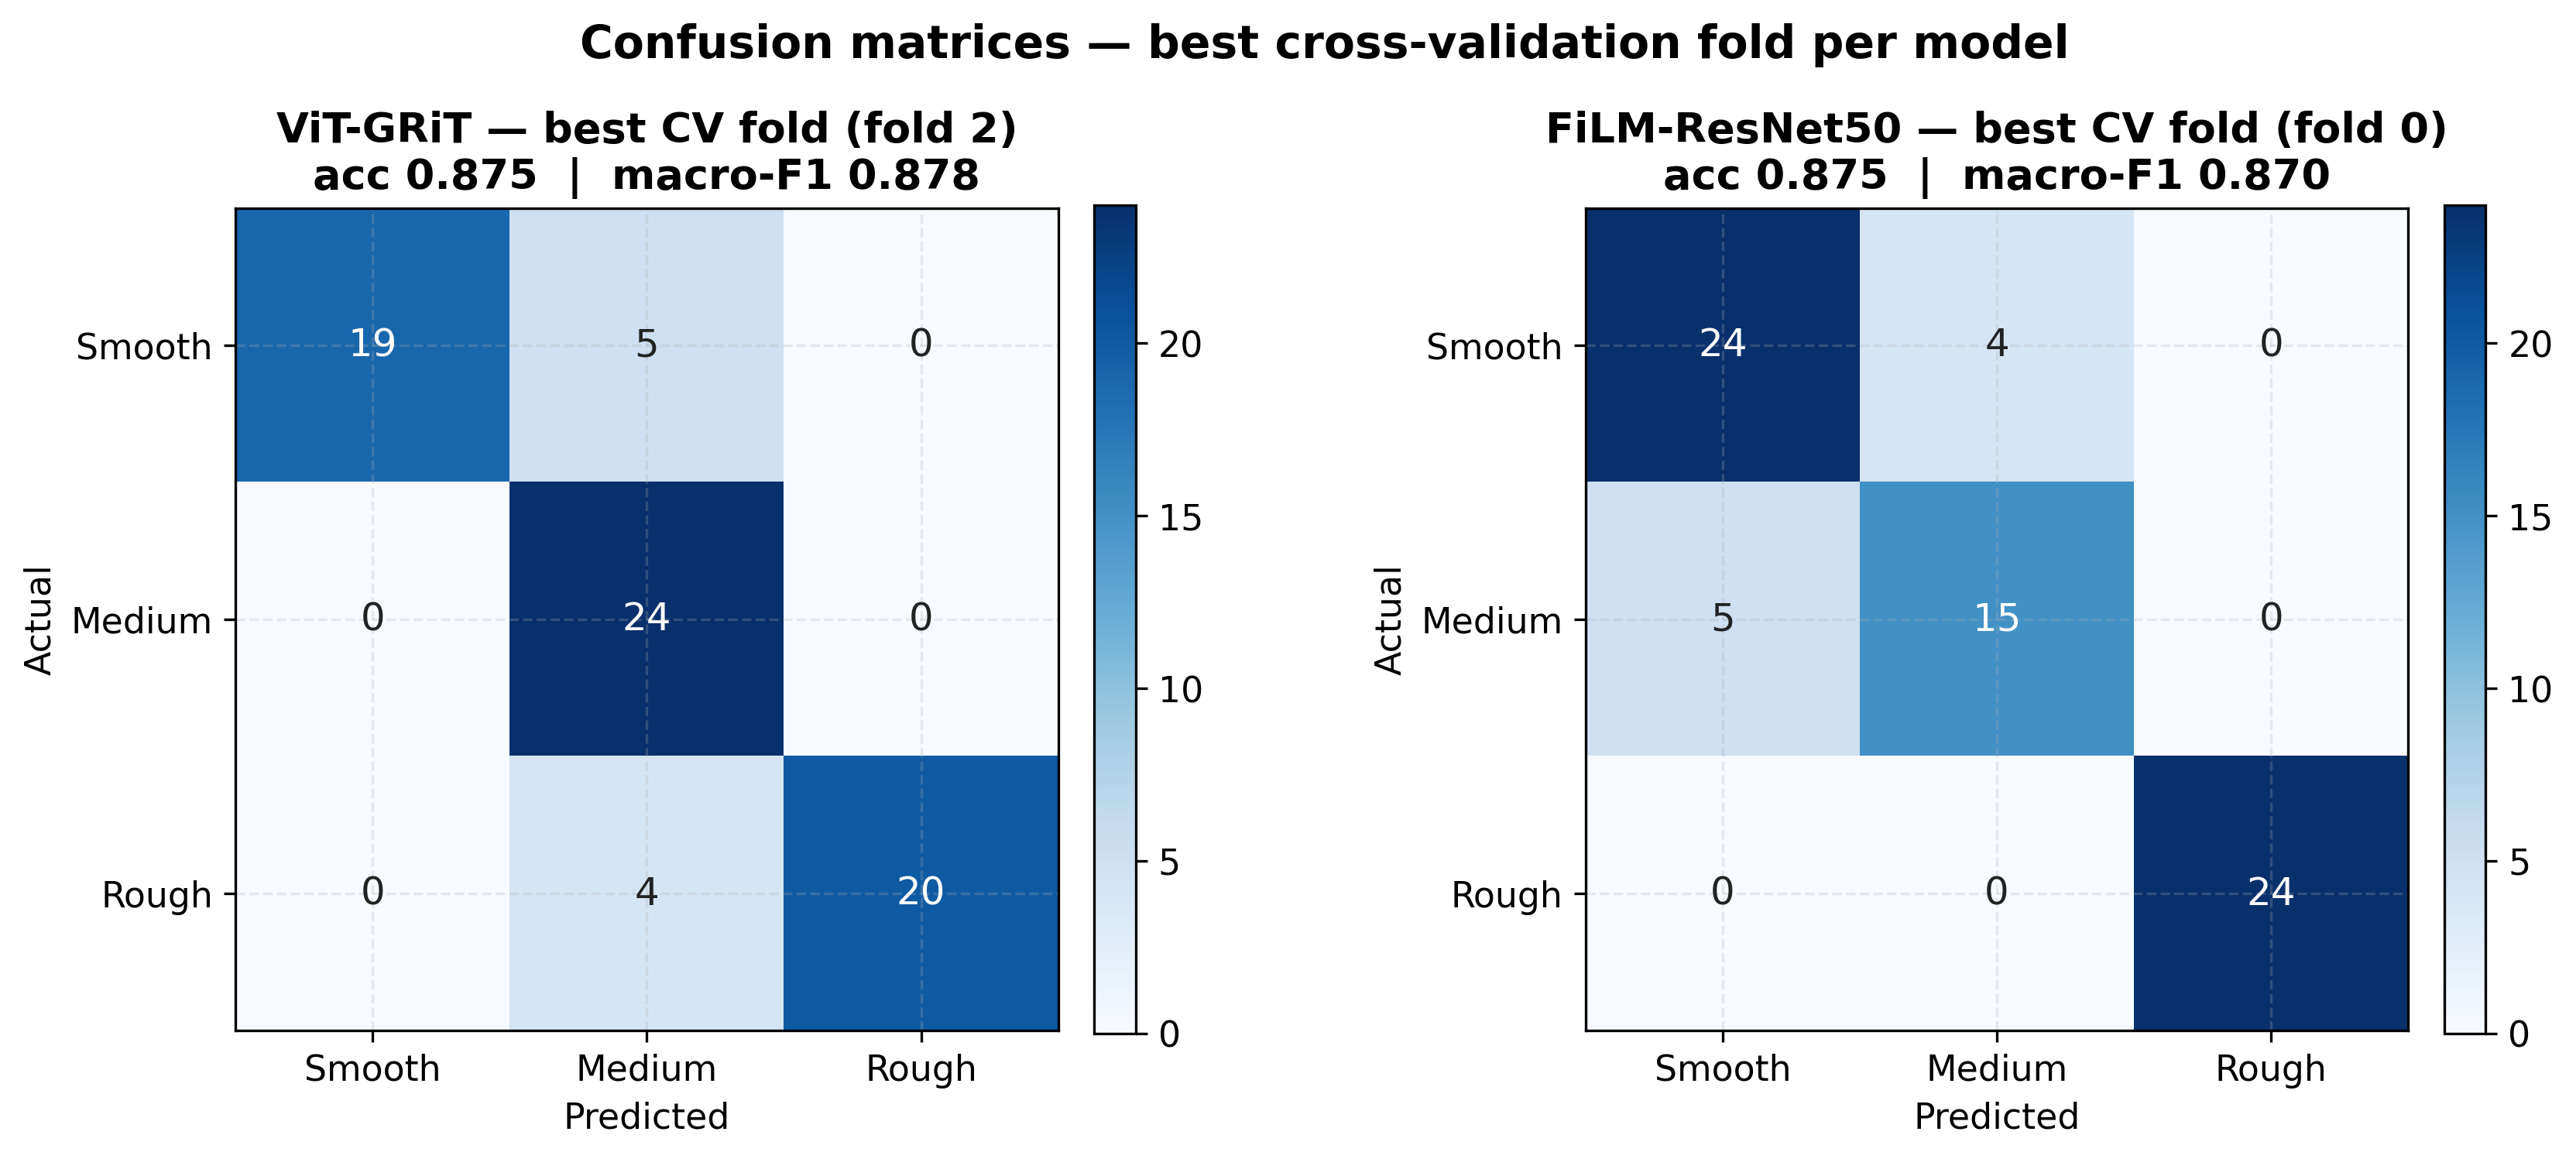

In [6]:
show_figure("confusion_matrices.png")

### 2.3 Training history (best CV fold per model)

Train/val loss and accuracy over epochs. ViT-GRiT's validation curve is noticeably
spikier (note the val-loss jump mid-training) — an early visual hint of the
instability the seed experiment later quantifies. FiLM-ResNet50 converges more
smoothly. Both use early stopping on validation accuracy.

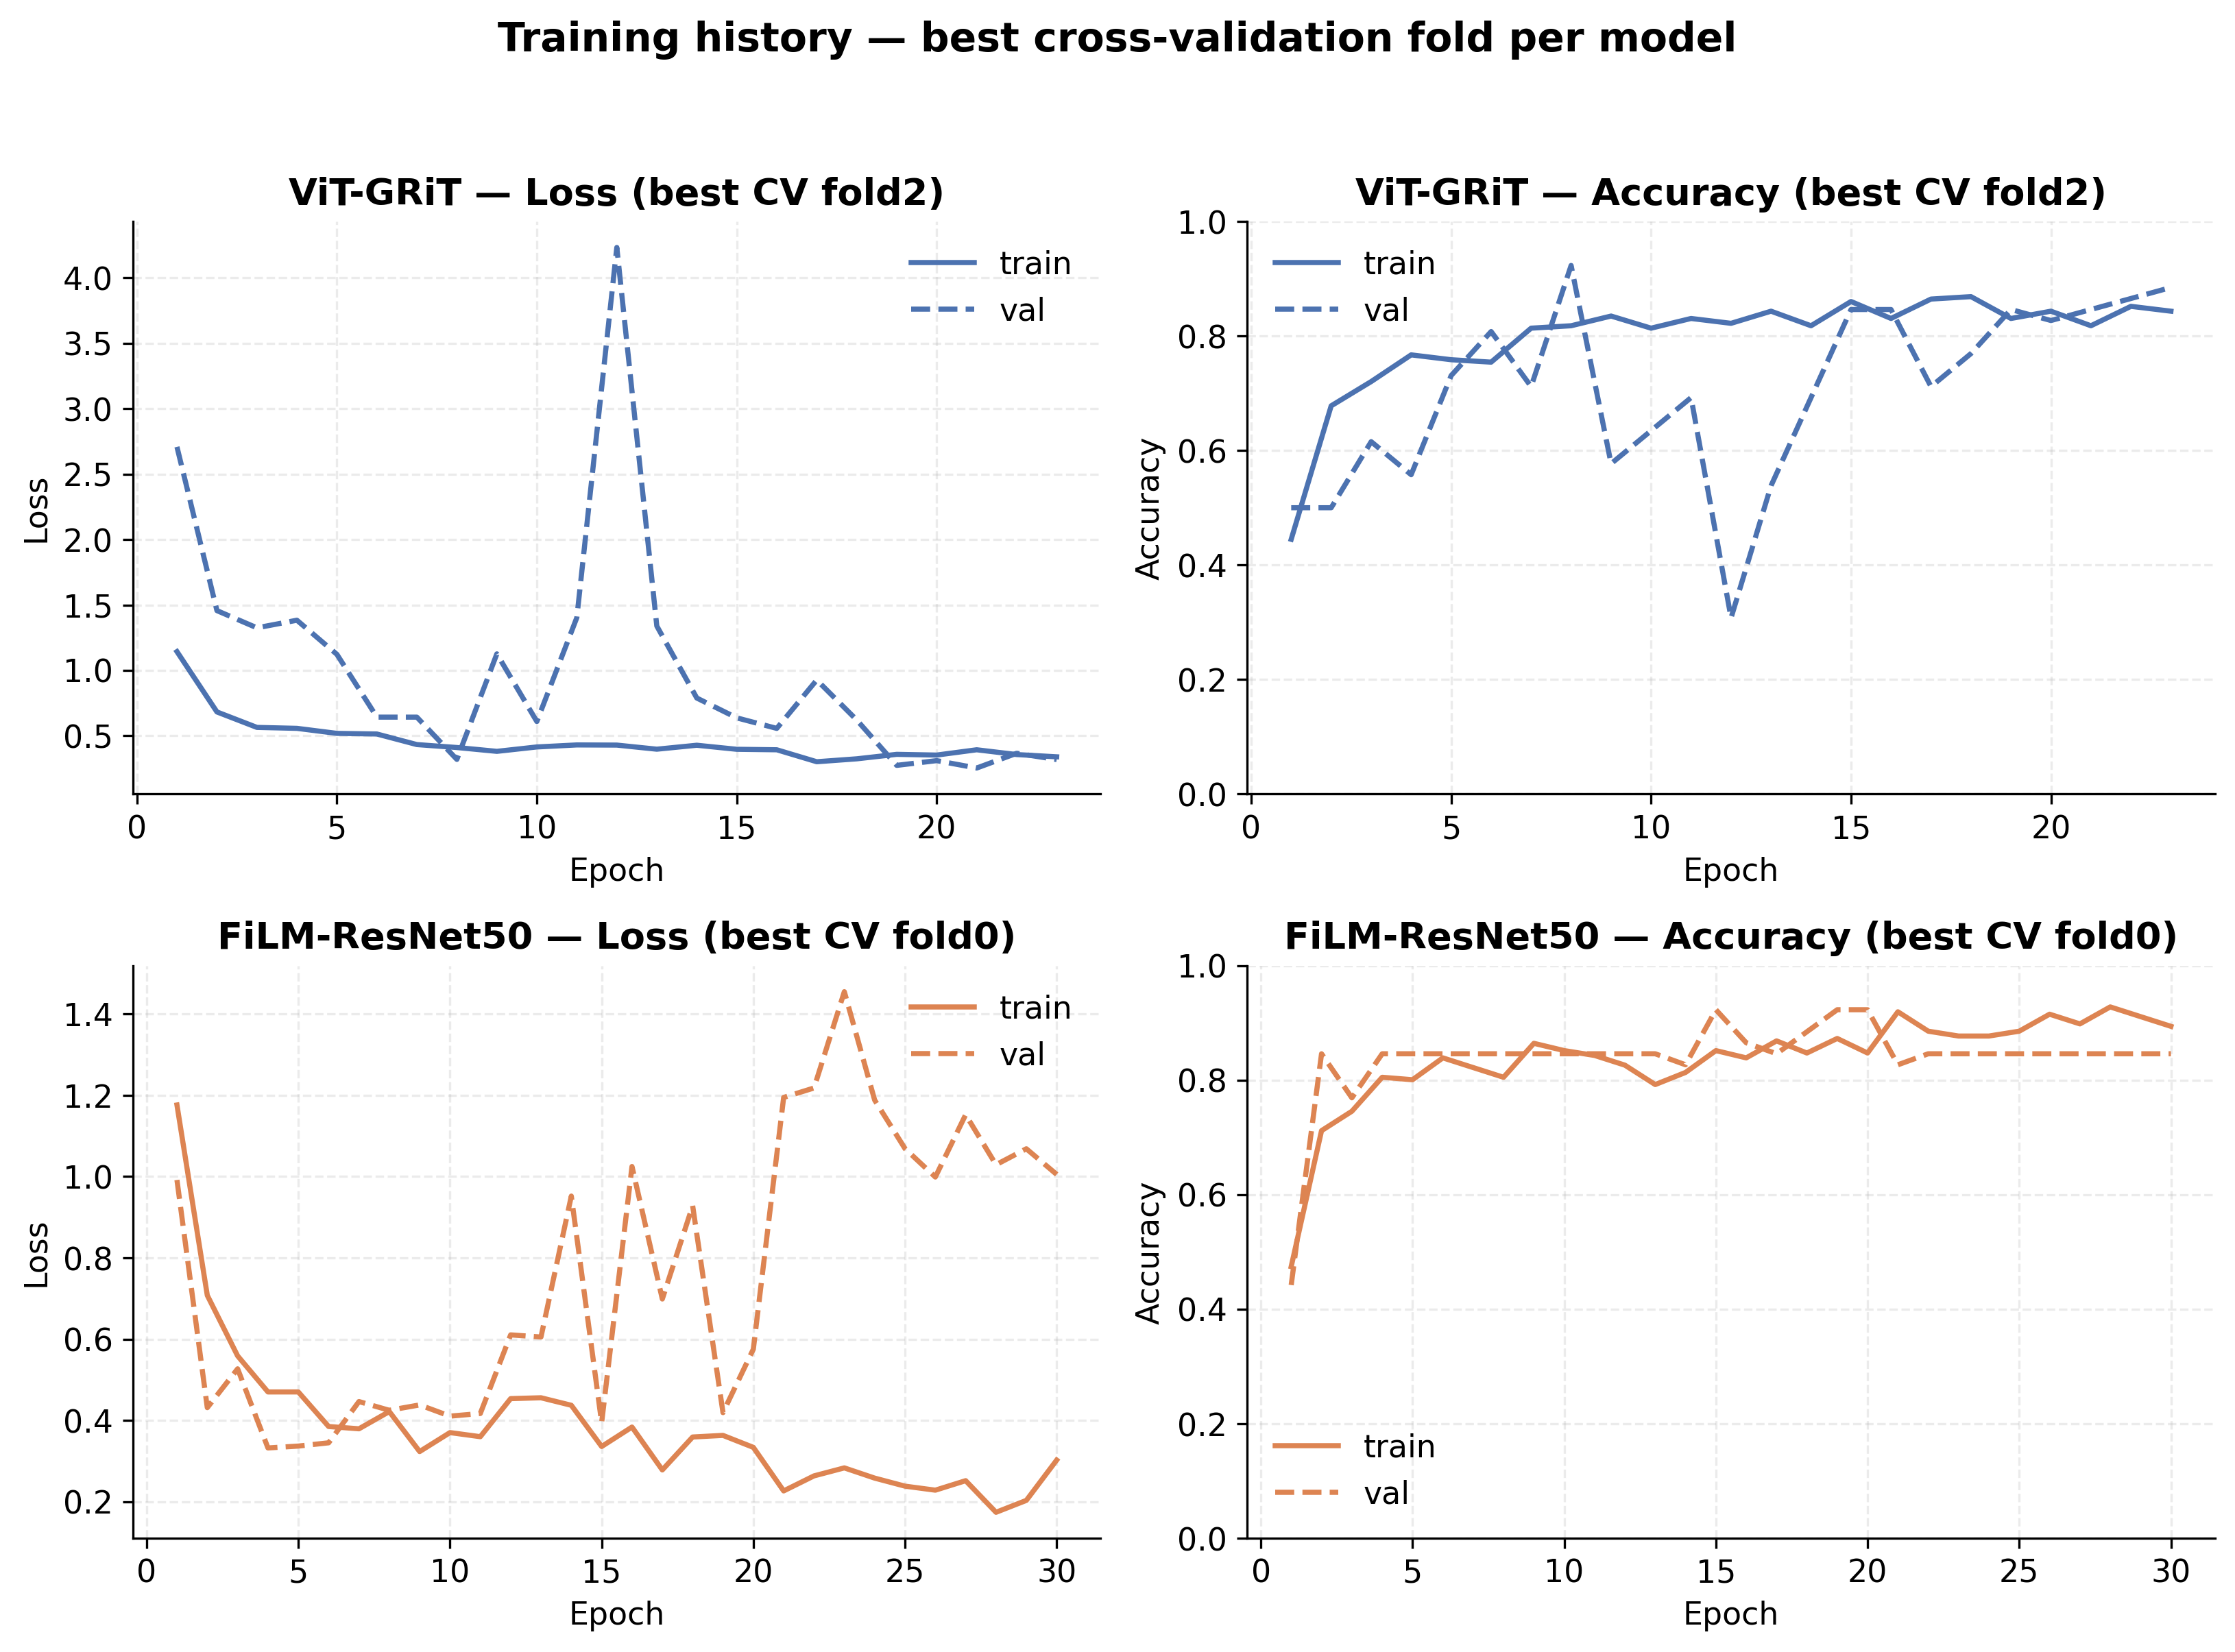

In [7]:
show_figure("training_history.png")

### 2.4 Per-class accuracy (aggregated over the full 5-fold CV)

Recall per class, summed over all five folds (every one of the 360 images is a
test image exactly once). This is where the two models diverge in an interesting
way — see the key findings below.

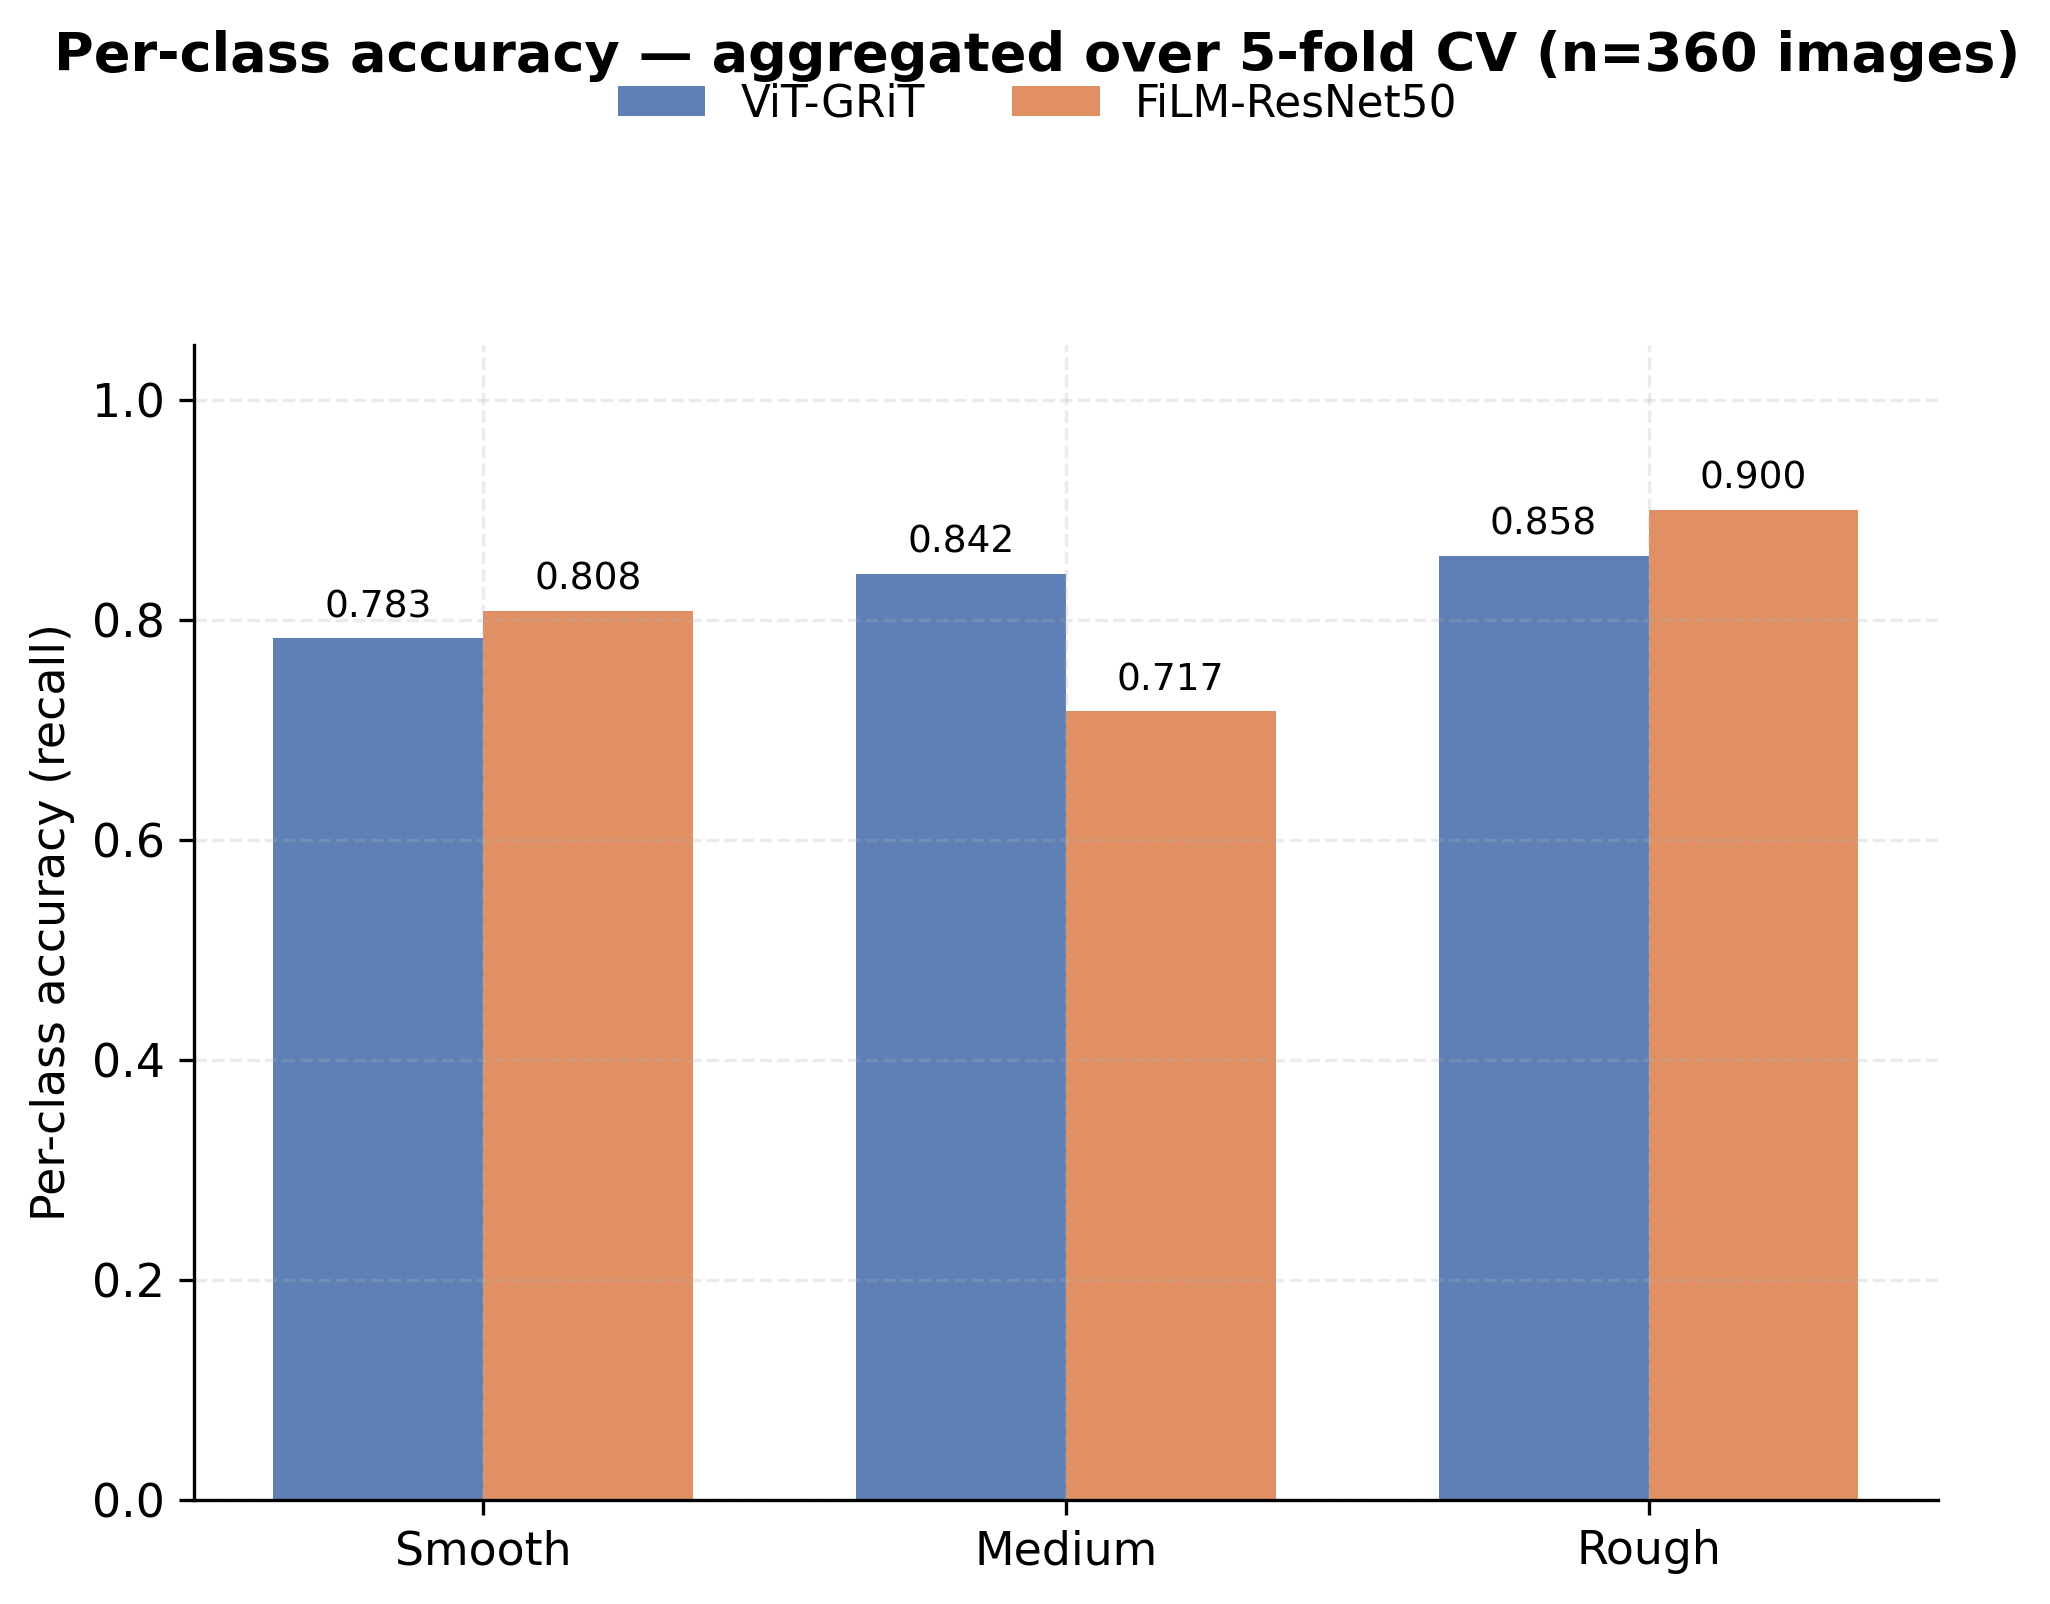

In [8]:
show_figure("per_class_accuracy.png")

## 3. Key findings

The averages hide the real story; the per-seed and per-class breakdowns reveal it.

1. **ViT-GRiT — higher ceiling, unstable.** It posts the best individual results,
   but on a *fixed* test set its accuracy swings wildly across training seeds, and
   one seed collapses badly.
2. **FiLM-ResNet50 — stable and dependable.** Its fixed-split accuracy barely
   moves across seeds, so its results are essentially reproducible, at a mean
   that's only marginally below ViT-GRiT's CV mean.
3. **Complementary class strengths.** The two models are not redundant — each wins
   different classes, which hints that an ensemble could beat either alone.

The two cells below quantify points 1–2 and point 3 directly from the data.

In [9]:
# Points 1-2: per-seed accuracy on the fixed test set, and the stability gap.
per_seed = pd.DataFrame({m: fixed[m]["acc"] for m in MODELS},
                        index=[f"seed {s}" for s in SEEDS]).round(4)

vit, film = fixed["ViT-GRiT"]["acc"], fixed["FiLM-ResNet50"]["acc"]
print(f"ViT-GRiT      fixed-split accuracy range: {vit.min():.3f}–{vit.max():.3f}  "
      f"(std {vit.std(ddof=1):.3f})")
print(f"FiLM-ResNet50 fixed-split accuracy range: {film.min():.3f}–{film.max():.3f}  "
      f"(std {film.std(ddof=1):.3f})")
print(f"-> ViT-GRiT is ~{vit.std(ddof=1) / film.std(ddof=1):.0f}x more sensitive to the training seed; "
      f"its worst seed collapsed to {vit.min():.3f}.")
per_seed

ViT-GRiT      fixed-split accuracy range: 0.571–0.839  (std 0.142)
FiLM-ResNet50 fixed-split accuracy range: 0.750–0.804  (std 0.027)
-> ViT-GRiT is ~5x more sensitive to the training seed; its worst seed collapsed to 0.571.


,ViT-GRiT,FiLM-ResNet50
seed 42,0.7857,0.8036
seed 123,0.5714,0.7857
seed 2024,0.8393,0.7500


In [10]:
# Point 3: per-class recall over the full 5-fold CV, and who wins each class.
def class_recall(cms):
    total = sum(cms)
    return {CLASSES[i]: total[i, i] / total[i].sum() for i in range(len(CLASSES))}

recall_table = pd.DataFrame({m: class_recall(cv[m]["cms"]) for m in MODELS}).reindex(CLASSES)

for cls in CLASSES:
    a, b = recall_table.loc[cls, "ViT-GRiT"], recall_table.loc[cls, "FiLM-ResNet50"]
    winner = "ViT-GRiT" if a > b else ("FiLM-ResNet50" if b > a else "tie")
    print(f"{cls:7}: ViT-GRiT {a:.3f}  vs  FiLM-ResNet50 {b:.3f}   ->  {winner}")

recall_table.round(3)

Smooth : ViT-GRiT 0.783  vs  FiLM-ResNet50 0.808   ->  FiLM-ResNet50
Medium : ViT-GRiT 0.842  vs  FiLM-ResNet50 0.717   ->  ViT-GRiT
Rough  : ViT-GRiT 0.858  vs  FiLM-ResNet50 0.900   ->  FiLM-ResNet50


,ViT-GRiT,FiLM-ResNet50
Smooth,0.783,0.808
Medium,0.842,0.717
Rough,0.858,0.900


**Reading the tables.**
- The per-seed table makes the trade-off concrete: ViT-GRiT can be the best *or*
  the worst model depending purely on the training seed, while FiLM-ResNet50 lands
  in the same narrow band every time.
- The per-class table shows the complementarity: the two backbones specialise on
  different roughness classes, so their errors are partly uncorrelated — fertile
  ground for a simple averaging ensemble.

## 4. Conclusion & recommendation

**Recommendation: ship FiLM-ResNet50 as the default model.**

- **Reproducibility wins in production.** FiLM-ResNet50's accuracy is essentially
  flat across training seeds, so retraining yields a predictable model — exactly
  what a deployed system needs. ViT-GRiT's seed-to-seed volatility (including an
  outright collapse on one seed) is a real operational risk.
- **The accuracy gap is within noise.** Under 5-fold CV the two models' means sit
  inside each other's error bars, so ViT-GRiT's "higher ceiling" is not a
  dependable advantage — you'd have to seed-search to realise it.

**When to prefer ViT-GRiT:** if you are chasing peak accuracy for a one-off result
and can afford a seed search plus stabilisation (lower LR / longer warm-up /
seed-averaging), ViT-GRiT has the higher upside.

**Most promising next step:** because the models have *complementary* per-class
strengths (ViT-GRiT stronger on Medium, FiLM-ResNet50 stronger on Rough), a simple
**2-model ensemble** is the natural way to get both the stability and the peak —
worth trying before any further single-model tuning.